# Runs all QM8 experiments with the full dataset!

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

Apparently 0.015 is what multitask will get, and 0.0143 is the best (MPNN)

In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM8"
test_file='qm8.csv'
data_file_name='qm8_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

num_repeats=3
num_epochs = 3

metric_labels=['mean_squared_error','pearson_r2_score',
               'mae_score', 'rmse']


metric1 = dc.metrics.Metric(dc.metrics.mean_squared_error)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3]
selected_metric = 2 #which metric to use for callback

TensorFlow version: 2.5.0
DeepChem version: 2.5.0


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

In [3]:
hdf5_file_name='qm8_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	21747
num_of_molecules is:	 128
MolID: count
Counter({127: 21620, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [4]:
fh.keys()

<KeysViewHDF5 ['E1-CAM', 'E1-CC2', 'E1-PBE0', 'E1-PBE0_2', 'E2-CAM', 'E2-CC2', 'E2-PBE0', 'E2-PBE0_2', 'PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'f1-CAM', 'f1-CC2', 'f1-PBE0', 'f1-PBE0_2', 'f2-CAM', 'f2-CC2', 'f2-PBE0', 'f2-PBE0_2', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'wasser_1', 'wasser_2', 'wasser_3']>

In [5]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['E1-CC2','E2-CC2','f1-CC2','f2-CC2',
             'E1-PBE0','E2-PBE0','f1-PBE0','f2-PBE0',
             'E1-PBE0_2','E2-PBE0_2','f1-PBE0_2','f2-PBE0_2',
             'E1-CAM','E2-CAM','f1-CAM','f2-CAM']

## Functions

In [6]:
metric_labels

['mean_squared_error', 'pearson_r2_score', 'mae_score', 'rmse']

In [7]:
def load_all_hdf5(fh,
                  num_of_rows, 
                  column_headers):
    """If dataset is small enough, load it all into memory
    fh = file handle
    num_of_rows = number of rows of data (i.e. molecules)
    column_headers into the hdf5 file"""
    data = np.zeros((num_of_rows,len(column_headers)))
    for key_num in range(len(column_headers)):
        key = column_headers[key_num]
        #print(key_num)
        d=fh[key]
        data[:,key_num] = d
    return data

def do_transform(transformers, dataset):
    for transformer in transformers:
        dataset = transformer.transform(dataset)
    return dataset

################## not copied into helper yet ####################

def get_them_metrics(
    model,
    datasets,
    metrics,
    metric_labels,
    transformers=[],
):
    """gross function meh gets data tho"""
    ugh=[]
    for dataset in datasets:
        if transformers == []:
            egg=model.evaluate(
                dataset, 
                metrics)
        else:
            egg=model.evaluate(
                dataset, 
                metrics,
                transformers = transformers)
        for metric_label in metric_labels:
            if metric_label == 'rmse':
                ugh.append(np.sqrt(egg['mean_squared_error']))
            else:
                ugh.append(egg[metric_label])
    return ugh

def topol_regression_experiment(
    dataset,
    transformers,
    Splitter_Object,
    tasks,
    metrics,
    metric_selector,
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
        dataset=dataset,
        frac_train=frac_train,
        frac_valid=frac_valid,
        frac_test=frac_test)
        # transforms datasets wooo 
        train_dataset=do_transform(transformers, train_dataset)
        valid_dataset=do_transform(transformers, valid_dataset)
        test_dataset=do_transform(transformers, test_dataset)
        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse','tr_r2','tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse', 'te_r2', 'te_mae','te_rmse'])
    return pd_out

def no_transform_topol_regression_experiment(
    dataset,
    Splitter_Object,
    tasks,
    metrics,
    metric_selector,
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
        dataset=dataset,
        frac_train=frac_train,
        frac_valid=frac_valid,
        frac_test=frac_test)
        # transforms datasets wooo 
        #train_dataset=do_transform(transformers, train_dataset)
        #valid_dataset=do_transform(transformers, valid_dataset)
        #test_dataset=do_transform(transformers, test_dataset)
        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers=[]))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse','tr_r2','tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse', 'te_r2', 'te_mae','te_rmse'])
    return pd_out



# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [8]:
## loading data from the hdf5 file
X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = fh['SMILES']

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# setting up the splitters for the task
Splitter_Object_tf = dc.splits.RandomSplitter()
Splitter_Object_pca = dc.splits.RandomSplitter()

# doing a transform on the data to make it easier for hte NN
# both y and x
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=pca_dataset)]



Text(0, 0.5, 'No.')

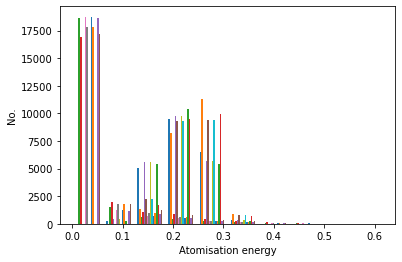

In [9]:
plt.hist(y_data)
plt.xlabel('Atomisation energy')
plt.ylabel("No.")

# Training on the topological features

In [10]:
        %%time
        Splitter_Object=Splitter_Object_tf
        transformers=transformers_tf
        dataset=topol_dataset
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
        dataset=dataset,
        frac_train=0.8,
        frac_valid=0.1,
        frac_test=0.1)
        # transforms datasets wooo 
        train_dataset=do_transform(transformers, train_dataset)
        valid_dataset=do_transform(transformers, valid_dataset)
        test_dataset=do_transform(transformers, test_dataset)
        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(task_list),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            5, 
            metrics[2])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

Step 5 validation: mae_score=0.789331
Step 10 validation: mae_score=0.79501
Step 15 validation: mae_score=0.697137
Step 20 validation: mae_score=0.771197
Step 25 validation: mae_score=0.742226
Step 30 validation: mae_score=0.706055
Step 35 validation: mae_score=0.730552
Step 40 validation: mae_score=0.700781
Step 45 validation: mae_score=0.739114
Step 50 validation: mae_score=0.701451
Step 55 validation: mae_score=0.724375
Step 60 validation: mae_score=0.695272
Step 65 validation: mae_score=0.717921
Step 70 validation: mae_score=0.730001
Step 75 validation: mae_score=0.672065
Step 80 validation: mae_score=0.749073
Step 85 validation: mae_score=0.692199
Step 90 validation: mae_score=0.733535
Step 95 validation: mae_score=0.674811
Step 100 validation: mae_score=0.765138
Step 105 validation: mae_score=0.687295
Step 110 validation: mae_score=0.729758
Step 115 validation: mae_score=0.70909
Step 120 validation: mae_score=0.725154
Step 125 validation: mae_score=0.718649
Step 130 validation: m

1.0141927545720881

In [11]:
%%time
output_metrics_tf=topol_regression_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter_Object_tf,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score', 
                   'mae_score', 
                   'rmse']
    )
output_metrics_tf

Metric selected is mae_score
Step 15 validation: mae_score=0.713988
Step 30 validation: mae_score=0.702874
Step 45 validation: mae_score=0.685742
Step 60 validation: mae_score=0.747007
Step 75 validation: mae_score=0.709193
Step 90 validation: mae_score=0.715574
Step 105 validation: mae_score=0.701476
Step 120 validation: mae_score=0.706297
Step 135 validation: mae_score=0.696059
Step 150 validation: mae_score=0.710623
Step 165 validation: mae_score=0.738704
Step 180 validation: mae_score=0.724531
Step 195 validation: mae_score=0.704164
Step 210 validation: mae_score=0.793138
Step 225 validation: mae_score=0.695826
Step 240 validation: mae_score=0.707749
Step 255 validation: mae_score=0.700905
Step 270 validation: mae_score=0.702541
Step 285 validation: mae_score=0.710093
Step 300 validation: mae_score=0.726737
Step 315 validation: mae_score=0.76099
Step 330 validation: mae_score=0.732015
Step 345 validation: mae_score=0.709392
Step 360 validation: mae_score=0.700022
Step 375 validatio

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.003226,0.049837,0.041131,0.056796,0.003330,0.052331,0.041465,0.057705,0.003150,0.040398,0.040581,0.056128
1,0.003268,0.050011,0.041250,0.057168,0.003324,0.041376,0.041715,0.057656,0.003199,0.047229,0.041623,0.056563
2,0.003187,0.048530,0.038379,0.056455,0.003179,0.048624,0.038596,0.056386,0.003092,0.039372,0.037944,0.055603


In [12]:
%%time
output_metrics_pca=topol_regression_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca

Metric selected is mae_score
Step 15 validation: mae_score=0.740996
Step 30 validation: mae_score=0.726565
Step 45 validation: mae_score=0.717453
Step 60 validation: mae_score=0.716276
Step 75 validation: mae_score=0.731539
Step 90 validation: mae_score=0.736829
Step 105 validation: mae_score=0.736587
Step 120 validation: mae_score=0.848262
Step 135 validation: mae_score=0.703412
Step 150 validation: mae_score=0.729515
Step 165 validation: mae_score=0.953549
Step 180 validation: mae_score=0.943776
Step 195 validation: mae_score=0.823142
Step 210 validation: mae_score=0.818155
Step 225 validation: mae_score=0.724159
Step 240 validation: mae_score=0.734204
Step 255 validation: mae_score=0.823891
Step 270 validation: mae_score=0.756776
Step 285 validation: mae_score=0.805889
Step 300 validation: mae_score=0.714434
Step 315 validation: mae_score=0.716705
Step 330 validation: mae_score=0.825866
Step 345 validation: mae_score=1.60728
Step 360 validation: mae_score=1.19525
Step 375 validation

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,5.826207,0.000250,0.090250,2.413754,0.019117,0.002194,0.074030,0.138263,0.016579,0.002029,0.074111,0.128758
1,0.361646,0.000132,0.046268,0.601370,0.005217,0.003587,0.043461,0.072227,0.003434,0.023053,0.041362,0.058601
2,14.458116,0.000090,0.079128,3.802383,0.005687,0.002492,0.043877,0.075411,0.037840,0.000279,0.048048,0.194524


In [13]:
%%time
output_metrics_pca_no_transform=no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter_Object_pca,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

Metric selected is mae_score
Step 15 validation: mae_score=0.288911
Step 30 validation: mae_score=0.214652
Step 45 validation: mae_score=0.124914
Step 60 validation: mae_score=0.249525
Step 75 validation: mae_score=0.229928
Step 90 validation: mae_score=0.123584
Step 105 validation: mae_score=0.396477
Step 120 validation: mae_score=0.239023
Step 135 validation: mae_score=0.246763
Step 150 validation: mae_score=0.120155
Step 165 validation: mae_score=0.318364
Step 180 validation: mae_score=0.184266
Step 195 validation: mae_score=0.515471
Step 210 validation: mae_score=0.465405
Step 225 validation: mae_score=0.2246
Step 240 validation: mae_score=0.195594
Step 255 validation: mae_score=0.214808
Step 270 validation: mae_score=0.216248
Step 285 validation: mae_score=0.553748
Step 300 validation: mae_score=0.385495
Step 315 validation: mae_score=0.524018
Step 330 validation: mae_score=0.309116
Step 345 validation: mae_score=0.676056
Step 360 validation: mae_score=0.641728
Step 375 validation

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,23991.287930,0.000091,2.396836,154.891213,66.730956,0.000233,1.243122,8.168902,18.111767,0.000684,1.113719,4.255792
1,3033.184936,0.000091,0.935091,55.074358,277.283603,0.000240,0.960870,16.651835,8.278149,0.000105,0.524794,2.877177
2,6.113311,0.000074,0.172546,2.472511,3628.685469,0.000737,1.256353,60.238571,0.134315,0.000753,0.137043,0.366491


## Dataset loaders for the other inputs if you want to play around with them

In [14]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm8(
    shard_size=2000, featurizer="ECFP", splitter="random")
train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
len(train_dataset_ECFP) + len(valid_dataset_ECFP) + len(test_dataset_ECFP)

21747

In [15]:
tasks

['E1-CC2',
 'E2-CC2',
 'f1-CC2',
 'f2-CC2',
 'E1-PBE0',
 'E2-PBE0',
 'f1-PBE0',
 'f2-PBE0',
 'E1-PBE0',
 'E2-PBE0',
 'f1-PBE0',
 'f2-PBE0',
 'E1-CAM',
 'E2-CAM',
 'f1-CAM',
 'f2-CAM']

In [16]:
featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
tasks, datasets, transformers_CM_eig = dc.molnet.load_qm8(
    shard_size=2000, featurizer=featurizer_CM_eig, splitter="random")
train_dataset_CM_eig, valid_dataset_CM_eig, test_dataset_CM_eig = datasets
len(train_dataset_CM_eig) + len(valid_dataset_CM_eig) + len(test_dataset_CM_eig)

21584

In [17]:
featurizer_weave = dc.feat.WeaveFeaturizer()
tasks, datasets, transformers_weave = dc.molnet.load_qm8(
    shard_size=2000, featurizer=featurizer_weave, splitter="random")
train_dataset_weave, valid_dataset_weave, test_dataset_weave = datasets
len(train_dataset_weave) + len(valid_dataset_weave) + len(test_dataset_weave)

21747

## Controls

In [18]:

        


## need to install stuff to do these
#featurizer = dc.feat.PubChemFingerprint()

#featurizer = dc.feat.Mol2VecFingerprint()

#featurizer = dc.feat.OneHotFeaturizer()

In [19]:
def dataset_selector(setting):
    """makes data inside experiment function
    """
    print('!!!!Make this function new for each new dataset!!!!')
    if setting == 'ECFP':
        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer="ECFP", splitter="random")
    elif setting == 'CM_eig':
        featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer=featurizer_CM_eig, splitter="random")
    elif setting == 'rdkit':
        featurizer_rdkit = dc.feat.RDKitDescriptors()
        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer=featurizer_rdkit, splitter="random")
        
    elif setting == 'MACCS':
        featurizer = dc.feat.MACCSKeysFingerprint()

        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer=featurizer, splitter="random")
    elif setting == '1HOT':
        featurizer = dc.feat.OneHotFeaturizer()

        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer=featurizer, splitter="random")
    elif setting == 'CM':
        featurizer = dc.feat.CoulombMatrix(max_atoms=23)
        tasks, datasets, transformers = dc.molnet.load_qm8(
            shard_size=2000, featurizer=featurizer, splitter="random")

    else:
        print('meh no data imported')
    return tasks, datasets, transformers

dataset_selector('CM')
#featurizer = dc.feat.CoulombMatrix(max_atoms=23)
#tasks, datasets, transformers = dc.molnet.load_qm8(
#    shard_size=2000, featurizer=featurizer, splitter="random")
#train_dataset, valid_dataset, test_dataset = datasets

#model=dc.models.DTNNModel(n_tasks = len(tasks), nb_epochs=3)
#model.fit(train_dataset, nb_epoch=3)

!!!!Make this function new for each new dataset!!!!


(['E1-CC2',
  'E2-CC2',
  'f1-CC2',
  'f2-CC2',
  'E1-PBE0',
  'E2-PBE0',
  'f1-PBE0',
  'f2-PBE0',
  'E1-PBE0',
  'E2-PBE0',
  'f1-PBE0',
  'f2-PBE0',
  'E1-CAM',
  'E2-CAM',
  'f1-CAM',
  'f2-CAM'],
 (<DiskDataset X.shape: (17267, 23, 23), y.shape: (17267, 16), w.shape: (17267, 16), task_names: ['E1-CC2' 'E2-CC2' 'f1-CC2' ... 'E2-CAM' 'f1-CAM' 'f2-CAM']>,
  <DiskDataset X.shape: (2158, 23, 23), y.shape: (2158, 16), w.shape: (2158, 16), task_names: ['E1-CC2' 'E2-CC2' 'f1-CC2' ... 'E2-CAM' 'f1-CAM' 'f2-CAM']>,
  <DiskDataset X.shape: (2159, 23, 23), y.shape: (2159, 16), w.shape: (2159, 16), task_names: ['E1-CC2' 'E2-CC2' 'f1-CC2' ... 'E2-CAM' 'f1-CAM' 'f2-CAM']>),
 [<deepchem.trans.transformers.NormalizationTransformer at 0x23d95233888>])

## ECFP

In [20]:

def deepchem_regression_experiment(
    metrics,
    metric_selector,
    setting='ECFP',
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        ################### this bit is different ##############
        print(f'Using dataset selector setting {setting}')
        tasks, datasets, transformers=dataset_selector(setting)
        train_dataset, valid_dataset, test_dataset = datasets
        task_list = tasks
        ########################################################
        # actual model here
        model = dc.models.MultitaskRegressor(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            #layer_sizes=[1000,1000,500,20],
            #dropouts=0.2,
            #learning_rate=0.001,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse', 'tr_r2', 'tr_mae','tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse','te_r2', 'te_mae', 'te_rmse'])
    return pd_out




In [21]:

def deepchem_CM_regression_experiment(
    metrics,
    metric_selector,
    setting='ECFP',
    num_repeats=5,
    num_epochs=250,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics
    
    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

## in function

    out=[]

    frac_train=split_fraction[0]
    frac_valid=split_fraction[1]
    frac_test=split_fraction[2]
    train_scores, validate_scores, test_scores = [],[],[]
    print(f'Metric selected is {metric_labels[metric_selector]}')
    for i in range(num_repeats):
        ################### this bit is different ##############
        print(f'Using dataset selector setting {setting}')
        tasks, datasets, transformers=dataset_selector(setting)
        train_dataset, valid_dataset, test_dataset = datasets
        task_list = tasks
        ########################################################
        # actual model here
        model=dc.models.DTNNModel(n_tasks = len(tasks), nb_epochs=3)
        callback = dc.models.ValidationCallback(
            valid_dataset, 
            patience, 
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))
    
    pd_out =pd.DataFrame(out, columns=['tr_mse', 'tr_r2', 'tr_mae', 'tr_rmse',
                              'val_mse', 'val_r2', 'val_mae','val_rmse',
                              'te_mse','te_r2', 'te_mae',  'te_rmse'])
    return pd_out




In [22]:
%%time
output_metrics_cm=deepchem_CM_regression_experiment(
    metrics,
    metric_selector=2,
    setting='CM',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_cm.head(3)

Metric selected is mae_score
Using dataset selector setting CM
!!!!Make this function new for each new dataset!!!!
Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.


C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_10/dtnn_step_1/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_10/dtnn_step_1/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_10/dtnn_step_1/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_10/dtnn_step/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_10/dtnn_step/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_10/dtnn_step/Cast

Step 15 validation: mae_score=0.820818
Step 30 validation: mae_score=0.745943
Step 45 validation: mae_score=0.71385
Step 60 validation: mae_score=0.713445
Step 75 validation: mae_score=0.713435
Step 90 validation: mae_score=0.696931
Step 105 validation: mae_score=0.680172
Step 120 validation: mae_score=0.689808
Step 135 validation: mae_score=0.695078
Step 150 validation: mae_score=0.688724
Step 165 validation: mae_score=0.691296
Step 180 validation: mae_score=0.663896
Step 195 validation: mae_score=0.71061
Step 210 validation: mae_score=0.673446
Step 225 validation: mae_score=0.682083
Step 240 validation: mae_score=0.689424
Step 255 validation: mae_score=0.711378
Step 270 validation: mae_score=0.703426
Step 285 validation: mae_score=0.691563
Step 300 validation: mae_score=0.661645
Step 315 validation: mae_score=0.659799
Step 330 validation: mae_score=0.663218
Step 345 validation: mae_score=0.696369
Step 360 validation: mae_score=0.71002
Step 375 validation: mae_score=0.688708
Step 390 

C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_11/dtnn_step_3/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_11/dtnn_step_3/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_11/dtnn_step_3/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_11/dtnn_step_2/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_11/dtnn_step_2/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_11/dtnn_step_

Step 15 validation: mae_score=0.795857
Step 30 validation: mae_score=0.738874
Step 45 validation: mae_score=0.716879
Step 60 validation: mae_score=0.702744
Step 75 validation: mae_score=0.693738
Step 90 validation: mae_score=0.701366
Step 105 validation: mae_score=0.709827
Step 120 validation: mae_score=0.696796
Step 135 validation: mae_score=0.680352
Step 150 validation: mae_score=0.686315
Step 165 validation: mae_score=0.687773
Step 180 validation: mae_score=0.688109
Step 195 validation: mae_score=0.685666
Step 210 validation: mae_score=0.682782
Step 225 validation: mae_score=0.6715
Step 240 validation: mae_score=0.670862
Step 255 validation: mae_score=0.679546
Step 270 validation: mae_score=0.705952
Step 285 validation: mae_score=0.67468
Step 300 validation: mae_score=0.660231
Step 315 validation: mae_score=0.715193
Step 330 validation: mae_score=0.683623
Step 345 validation: mae_score=0.670554
Step 360 validation: mae_score=0.67026
Step 375 validation: mae_score=0.678315
Step 390 v

C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_12/dtnn_step_5/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_12/dtnn_step_5/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_12/dtnn_step_5/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\.conda\envs\tdaf-tf2h\lib\site-packages\tensorflow\python\framework\indexed_slices.py:449: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/model_12/dtnn_step_4/Reshape_5:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/model_12/dtnn_step_4/Reshape_4:0", shape=(None, 60), dtype=float32), dense_shape=Tensor("gradient_tape/model_12/dtnn_step_

Step 15 validation: mae_score=0.863787
Step 30 validation: mae_score=0.761263
Step 45 validation: mae_score=0.74152
Step 60 validation: mae_score=0.719719
Step 75 validation: mae_score=0.714953
Step 90 validation: mae_score=0.705479
Step 105 validation: mae_score=0.710208
Step 120 validation: mae_score=0.695194
Step 135 validation: mae_score=0.695821
Step 150 validation: mae_score=0.687179
Step 165 validation: mae_score=0.681489
Step 180 validation: mae_score=0.685173
Step 195 validation: mae_score=0.687028
Step 210 validation: mae_score=0.692661
Step 225 validation: mae_score=0.702033
Step 240 validation: mae_score=0.681927
Step 255 validation: mae_score=0.679611
Step 270 validation: mae_score=0.678629
Step 285 validation: mae_score=0.656683
Step 300 validation: mae_score=0.704553
Step 315 validation: mae_score=0.694432
Step 330 validation: mae_score=0.681554
Step 345 validation: mae_score=0.675623
Step 360 validation: mae_score=0.671074
Step 375 validation: mae_score=0.662164
Step 39

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.003119,0.102670,0.035427,0.055846,0.003162,0.085248,0.035613,0.056232,0.003085,0.099137,0.035382,0.055539
1,0.003038,0.102494,0.037372,0.055117,0.003072,0.085182,0.037502,0.055429,0.002983,0.105836,0.037176,0.054617
2,0.003045,0.098586,0.037061,0.055182,0.003039,0.086041,0.036985,0.055124,0.002989,0.099296,0.036927,0.054675


# Control experiments:
regression first

In [23]:
%%time
output_metrics_ecfp = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='ECFP',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_ecfp

Metric selected is mae_score
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!
Step 15 validation: mae_score=0.688399
Step 30 validation: mae_score=0.706041
Step 45 validation: mae_score=0.702836
Step 60 validation: mae_score=0.718888
Step 75 validation: mae_score=0.677351
Step 90 validation: mae_score=0.678795
Step 105 validation: mae_score=0.691823
Step 120 validation: mae_score=0.742451
Step 135 validation: mae_score=0.669092
Step 150 validation: mae_score=0.684232
Step 165 validation: mae_score=0.725253
Step 180 validation: mae_score=0.712803
Step 195 validation: mae_score=0.683373
Step 210 validation: mae_score=0.681337
Step 225 validation: mae_score=0.69445
Step 240 validation: mae_score=0.660967
Step 255 validation: mae_score=0.659906
Step 270 validation: mae_score=0.65519
Step 285 validation: mae_score=0.660548
Step 300 validation: mae_score=0.658372
Step 315 validation: mae_score=0.660581
Step 330 validation: mae_score=0.681522
Step 345 va

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.002793,0.164079,0.036516,0.052849,0.002964,0.102444,0.037796,0.054438,0.003018,0.132628,0.037235,0.054939
1,0.002777,0.164939,0.035253,0.052701,0.002954,0.099954,0.036586,0.054346,0.003011,0.131411,0.036051,0.054869
2,0.002789,0.165073,0.035422,0.052815,0.002964,0.099694,0.036705,0.054442,0.003019,0.132005,0.036178,0.054943


### Coulomb matrix eigenvalues

In [24]:
%%time
output_metrics_cm_eig = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='CM_eig',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_cm_eig

Metric selected is mae_score
Using dataset selector setting CM_eig
!!!!Make this function new for each new dataset!!!!
Step 15 validation: mae_score=0.808743
Step 30 validation: mae_score=0.741553
Step 45 validation: mae_score=0.738085
Step 60 validation: mae_score=0.722927
Step 75 validation: mae_score=0.727793
Step 90 validation: mae_score=0.708233
Step 105 validation: mae_score=0.707803
Step 120 validation: mae_score=0.723282
Step 135 validation: mae_score=0.712186
Step 150 validation: mae_score=0.73254
Step 165 validation: mae_score=0.734895
Step 180 validation: mae_score=0.709947
Step 195 validation: mae_score=0.695418
Step 210 validation: mae_score=0.697757
Step 225 validation: mae_score=0.733072
Step 240 validation: mae_score=0.704266
Step 255 validation: mae_score=0.679421
Step 270 validation: mae_score=0.704298
Step 285 validation: mae_score=0.742811
Step 300 validation: mae_score=0.713938
Step 315 validation: mae_score=0.701548
Step 330 validation: mae_score=0.723823
Step 345

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.003206,0.033807,0.038747,0.056626,0.003191,0.039615,0.038550,0.056485,0.003595,0.038592,0.039821,0.059954
1,0.003202,0.035200,0.039620,0.056585,0.003181,0.043092,0.039399,0.056404,0.003585,0.041773,0.040673,0.059872
2,0.003191,0.033071,0.038096,0.056486,0.003177,0.039464,0.037906,0.056364,0.003581,0.039580,0.039106,0.059841


### rdkit features

In [25]:
%%time
output_metrics_rdkit = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='rdkit',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_rdkit

Metric selected is mae_score
Using dataset selector setting rdkit
!!!!Make this function new for each new dataset!!!!
Step 15 validation: mae_score=0.909826
Step 30 validation: mae_score=0.748367
Step 45 validation: mae_score=0.70691
Step 60 validation: mae_score=0.704136
Step 75 validation: mae_score=0.695083
Step 90 validation: mae_score=0.730026
Step 105 validation: mae_score=0.727583
Step 120 validation: mae_score=0.699966
Step 135 validation: mae_score=0.682703
Step 150 validation: mae_score=0.704179
Step 165 validation: mae_score=0.690684
Step 180 validation: mae_score=0.701856
Step 195 validation: mae_score=0.707577
Step 210 validation: mae_score=0.717107
Step 225 validation: mae_score=0.702741
Step 240 validation: mae_score=0.66073
Step 255 validation: mae_score=0.673487
Step 270 validation: mae_score=0.699462
Step 285 validation: mae_score=0.675874
Step 300 validation: mae_score=0.68443
Step 315 validation: mae_score=0.700284
Step 330 validation: mae_score=0.688163
Step 345 va

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.003036,0.091041,0.037689,0.055098,0.003250,0.084693,0.038376,0.057012,0.011376,0.010515,0.038949,0.106658
1,0.003095,0.092159,0.039613,0.055636,0.003297,0.089253,0.040248,0.057416,0.018660,0.017996,0.041369,0.136603
2,0.003090,0.078441,0.038449,0.055591,0.003307,0.075840,0.039175,0.057503,0.039360,0.003348,0.041769,0.198394


## MACCS features

In [26]:
%%time
output_metrics_maccs = deepchem_regression_experiment(
    metrics,
    metric_selector=selected_metric,
    setting='MACCS',
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=[0.8,0.1,0.1],
    patience=15,
    metric_labels=['mean_squared_error',
                   'pearson_r2_score',
                   'mae_score', 
                   'rmse'])
output_metrics_maccs

Metric selected is mae_score
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Step 15 validation: mae_score=0.711193
Step 30 validation: mae_score=0.710694
Step 45 validation: mae_score=0.708566
Step 60 validation: mae_score=0.707801
Step 75 validation: mae_score=0.689501
Step 90 validation: mae_score=0.694815
Step 105 validation: mae_score=0.731285
Step 120 validation: mae_score=0.705631
Step 135 validation: mae_score=0.713529
Step 150 validation: mae_score=0.728963
Step 165 validation: mae_score=0.715313
Step 180 validation: mae_score=0.694415
Step 195 validation: mae_score=0.692007
Step 210 validation: mae_score=0.700446
Step 225 validation: mae_score=0.714194
Step 240 validation: mae_score=0.729306
Step 255 validation: mae_score=0.717904
Step 270 validation: mae_score=0.708547
Step 285 validation: mae_score=0.695605
Step 300 validation: mae_score=0.705394
Step 315 validation: mae_score=0.692774
Step 330 validation: mae_score=0.684715
Step 345

,tr_mse,tr_r2,tr_mae,tr_rmse,val_mse,val_r2,val_mae,val_rmse,te_mse,te_r2,te_mae,te_rmse
0,0.002966,0.104116,0.035784,0.054465,0.003191,0.093355,0.036899,0.056488,0.003077,0.099716,0.036171,0.055470
1,0.002952,0.104721,0.036829,0.054330,0.003174,0.091504,0.037943,0.056338,0.003055,0.100079,0.037156,0.055274
2,0.002957,0.104726,0.036565,0.054379,0.003188,0.091805,0.037717,0.056465,0.003056,0.100906,0.036870,0.055277


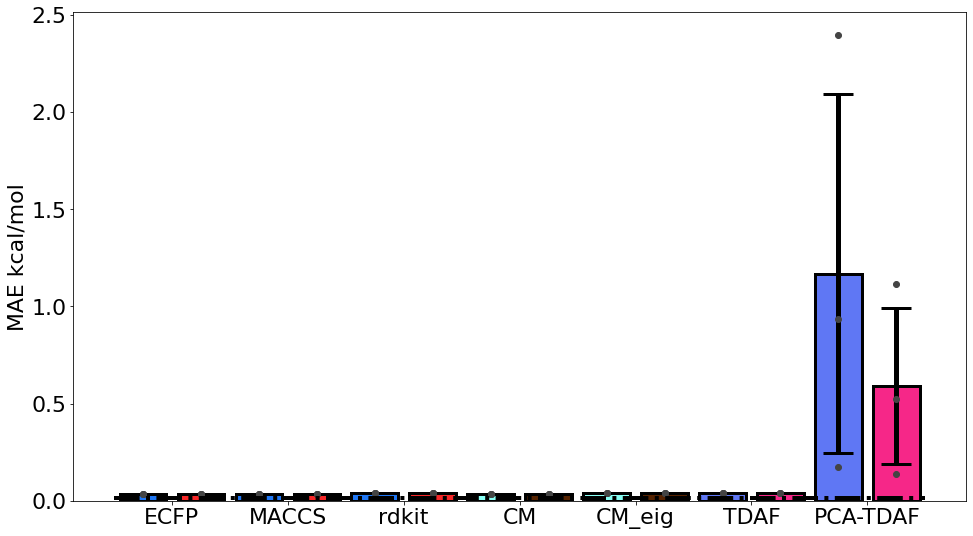

In [27]:
best=0.015

data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm['tr_mae'],
     output_metrics_cm['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca_no_transform['tr_mae'],
     output_metrics_pca_no_transform['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,14.5],[best, best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5,9.5,11.5,13.5],['ECFP',"MACCS","rdkit","CM","CM_eig","TDAF","PCA-TDAF"])
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, "QM8_rmse.png"))

In [28]:
list_of_data_frames=[output_metrics_ecfp,
     output_metrics_maccs,
     output_metrics_rdkit,
     output_metrics_cm,
     output_metrics_cm_eig,
     output_metrics_tf,
     output_metrics_pca_no_transform]

list_of_data_frames_names=["output_metrics_ecfp",
     "output_metrics_maccs",
     "output_metrics_rdkit",
     "output_metrics_cm",
     "output_metrics_cm_eig",
     "output_metrics_tf",
     "output_metrics_pca_no_transform"]

In [29]:
results_dir

'F:\\Nextcloud\\science\\results\\topology_and_graphs\\QM8'

In [30]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


# stuff that doesn't work yet

## Controls

In [31]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
    params_dict, 
    train_dataset_ECFP, 
    valid_dataset_ECFP, 
    metric, 
    transformers)

NameError: name 'my_dataset' is not defined

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ECFP, validate_scores_ECFP, test_scores_ECFP = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_ECFP.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ECFP.append(model.evaluate(valid_dataset_ECFP,
                                          metric1)['mae_score'])
    test_scores_ECFP.append(model.evaluate(test_dataset_ECFP,
                                      metric1)['mae_score'])

In [ ]:
test_scores_ECFP

In [ ]:

transformers[1].untransform(test_scores_ECFP[0])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
# the splitter does not shuffle the data
tasks, datasets, transformers = dc.molnet.load_qm8(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")
sdf_train_dataset, sdf_valid_dataset, sdf_test_dataset = datasets

In [ ]:

sdf_data_dir=r'F:\Nextcloud\science\Datasets'


In [ ]:
tasks = ["atomization_energy"]
sdf_filename='gdb7.sdf'
#dataset_file = "../../datasets/gdb1k.sdf"
smiles_field = "smiles"
mol_field = "mol"

In [ ]:
featurizer_CM = dc.feat.CoulombMatrixEig(23, remove_hydrogens=False)
loader = dc.data.SDFLoader(
      tasks=["u0_atom"],
      featurizer=featurizer_CM)
dataset = loader.create_dataset(os.path.join(sdf_data_dir, sdf_filename))

In [ ]:

random_splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = random_splitter.train_valid_test_split(dataset)

In [ ]:
transformers = [
    dc.trans.NormalizationTransformer(transform_X=True, dataset=train_dataset),
    dc.trans.NormalizationTransformer(transform_y=True, dataset=train_dataset)]

for dataset in [train_dataset, valid_dataset, test_dataset]:
  for transformer in transformers:
      dataset = transformer.transform(dataset)

In [ ]:
def rf_model_builder(model_dir, **model_params):
  sklearn_model = RandomForestRegressor(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)
params_dict = {
    "n_estimators": [10, 100],
    "max_features": ["auto", "sqrt", "log2", None],
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(rf_model_builder)
best_rf, best_rf_hyperparams, all_rf_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_rf_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_rf_hyperparams)

In [ ]:

def krr_model_builder(model_dir, **model_params):
  sklearn_model = KernelRidge(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)

params_dict = {
    "kernel": ["laplacian"],
    "alpha": [0.0001],
    "gamma": [0.0001]
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(krr_model_builder)
best_krr, best_krr_hyperparams, all_krr_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_krr_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_krr_hyperparams)

In [ ]:
best_krr.model.score(test_dataset.X, test_dataset.y)

In [ ]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
fh.close()